### EDA do experimento `collection_models` (MLflow)

Carrega os runs de um experimento `collection_*` como DataFrame via
`mlflow.search_runs`, para comparar modelos sem abrir a UI run a run.
Reutilizável: troque `EXPERIMENT_NAME` para apontar a outro experimento
com a mesma convenção de métricas (`<saida>__<metrica>`,
`freq__<saida>__<banda>__<metrica>`), gerada por
`collection_common.py`/`05_collection_models_v1.py`.

Só lê métricas já registradas — não reprocessa pesos nem refaz
forecast.

In [1]:
from pathlib import Path

import mlflow
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

MLFLOW_DB = Path("../training/mlflow.db")
EXPERIMENT_NAME = "mimo_sys_collection_70_15_15"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")

/home/rwp/code/mimo_sys/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Runs do experimento

In [2]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
children = runs[runs["tags.mlflow.parentRunId"].notna()].copy()
children = children.rename(columns={"tags.mlflow.runName": "modelo"})
children = children.set_index("modelo")

print(f"{len(children)} modelos em '{EXPERIMENT_NAME}'")
children[["status", "start_time"]]

7 modelos em 'mimo_sys_collection_70_15_15'


,status,start_time
modelo,,
Seq2SeqLatentGNN,FINISHED,2026-10-09 17:08:01.836000+00:00
StemGNN,FINISHED,2026-10-09 17:07:53.548000+00:00
SymbolicGraphNetwork,FINISHED,2026-10-09 17:07:47.890000+00:00
MPNN,FINISHED,2026-10-09 17:07:42.212000+00:00
Seq2SeqAttention,FINISHED,2026-10-09 17:07:37.111000+00:00
ARMAX 12 passos,FINISHED,2026-10-09 17:07:33.837000+00:00
ARMAX 1 passo,FINISHED,2026-10-09 17:07:29.572000+00:00


### Métricas por saída

Uma linha por modelo, R²/MSE/MAE/SMAPE por saída — o mesmo que a aba
*Metrics* de cada child run, mas lado a lado.

In [3]:
OUTPUT_COLS = ["vazao_distribuicao", "nivel_res", "pressao"]
BASE_METRICS = ["r2", "mse", "mae", "smape_pct"]


def metric_table(metric: str) -> pd.DataFrame:
    """Uma coluna por saída para `metric` (ex.: 'r2', 'smape_pct')."""
    cols = {out: f"metrics.{out}__{metric}" for out in OUTPUT_COLS}
    return children[list(cols.values())].rename(
        columns={v: k for k, v in cols.items()}
    )


r2 = metric_table("r2")
r2.round(3).sort_values("vazao_distribuicao", ascending=False)

,vazao_distribuicao,nivel_res,pressao
modelo,,,
SymbolicGraphNetwork,0.915,0.260,0.693
ARMAX 1 passo,0.915,0.932,0.630
MPNN,0.909,0.248,0.667
StemGNN,0.889,0.386,0.594
Seq2SeqAttention,0.877,0.435,0.653
Seq2SeqLatentGNN,0.875,0.304,0.633
ARMAX 12 passos,0.569,0.285,0.144


In [4]:
smape = metric_table("smape_pct")
smape.round(2).sort_values("vazao_distribuicao")

,vazao_distribuicao,nivel_res,pressao
modelo,,,
ARMAX 1 passo,8.05,1.75,6.08
SymbolicGraphNetwork,8.40,6.39,6.32
MPNN,8.68,6.34,6.81
Seq2SeqAttention,9.70,5.46,6.54
StemGNN,10.15,5.40,7.75
Seq2SeqLatentGNN,10.57,6.14,7.23
ARMAX 12 passos,19.90,5.86,12.27


In [5]:
summary_cols = {
    "r2_medio": "metrics.r2_medio",
    "smape_medio_%": "metrics.smape_medio_pct",
    "mse_medio": "metrics.mse_medio",
}
children[list(summary_cols.values())].rename(
    columns={v: k for k, v in summary_cols.items()}
).round(3).sort_values("r2_medio", ascending=False)

,r2_medio,smape_medio_%,mse_medio
modelo,,,
ARMAX 1 passo,0.826,5.294,19.640
Seq2SeqAttention,0.655,7.236,27.348
StemGNN,0.623,7.768,25.229
SymbolicGraphNetwork,0.623,7.039,19.362
MPNN,0.608,7.277,20.705
Seq2SeqLatentGNN,0.604,7.981,28.017
ARMAX 12 passos,0.333,12.678,94.405


### Métricas no domínio da frequência

Erro de energia por banda espectral (`docs/5_eda-series-temporais.md`
§7) e por saída, reconstruído a partir das colunas
`freq__<saida>__<banda>__energia_rel_pct` em formato longo.

In [6]:
freq_cols = [c for c in children.columns if c.startswith("metrics.freq__")]

freq_long = (
    children[freq_cols]
    .reset_index()
    .melt(id_vars="modelo", var_name="col", value_name="valor")
)
parts = freq_long["col"].str.removeprefix("metrics.freq__").str.split("__")
freq_long["saida"] = parts.str[0]
freq_long["banda"] = parts.str[1]
freq_long["metrica"] = parts.str[2]
freq_long = freq_long.drop(columns="col").dropna(subset="valor")

BAND_ORDER = [
    "tendencia_acima_32h",
    "diario_16-32h",
    "harmonico_8-16h",
    "curto_4-8h",
    "ruido_2-4h",
]


def band_pivot(output: str, metric: str = "energia_rel_pct") -> pd.DataFrame:
    """Modelo × banda para `output`, ordenado de tendência a ruído."""
    sub = freq_long[
        (freq_long["saida"] == output) & (freq_long["metrica"] == metric)
    ]
    pivot = sub.pivot(index="modelo", columns="banda", values="valor")
    return pivot[[b for b in BAND_ORDER if b in pivot.columns]]


band_pivot("vazao_distribuicao").round(1)

banda,tendencia_acima_32h,diario_16-32h,harmonico_8-16h,curto_4-8h,ruido_2-4h
modelo,,,,,
ARMAX 1 passo,-19.6,-12.5,9.1,28.4,42.1
ARMAX 12 passos,-3.3,-64.8,-39.6,36.6,-16.1
MPNN,-57.4,-1.1,-39.7,-64.9,-73.7
Seq2SeqAttention,-51.2,-0.3,-29.6,-50.3,-72.5
Seq2SeqLatentGNN,-68.4,-9.1,-57.4,-60.5,-65.2
StemGNN,-63.6,-9.8,-32.8,-60.1,-63.9
SymbolicGraphNetwork,-69.0,0.0,-30.1,-64.5,-72.2


In [7]:
band_pivot("nivel_res").round(1)

banda,tendencia_acima_32h,diario_16-32h,harmonico_8-16h,curto_4-8h,ruido_2-4h
modelo,,,,,
ARMAX 1 passo,3.6,4.2,22.9,62.7,438.0
ARMAX 12 passos,27.7,26.7,-19.7,17.5,301.8
MPNN,-59.1,70.1,-56.5,-42.6,170.2
Seq2SeqAttention,-50.2,76.0,-37.2,-13.9,45.1
Seq2SeqLatentGNN,-64.2,65.8,-41.3,-44.3,234.8
StemGNN,-53.4,-2.9,-37.2,-58.2,118.5
SymbolicGraphNetwork,-70.0,58.3,-59.9,-68.0,68.8


In [8]:
band_pivot("pressao").round(1)

banda,tendencia_acima_32h,diario_16-32h,harmonico_8-16h,curto_4-8h,ruido_2-4h
modelo,,,,,
ARMAX 1 passo,-16.1,-9.1,-6.2,-64.2,29.2
ARMAX 12 passos,155.4,-57.2,-38.6,-45.8,-71.5
MPNN,-57.0,-16.1,-65.2,-79.8,-91.1
Seq2SeqAttention,-19.5,16.3,-65.4,-63.9,-92.7
Seq2SeqLatentGNN,-30.1,11.6,-69.6,-73.1,-90.4
StemGNN,59.4,-11.8,-53.2,-71.7,-83.6
SymbolicGraphNetwork,-62.2,-15.2,-65.1,-85.3,-94.1


### Attention

Entropia relativa dos modelos com attention sobre lags — perto de 1,0
é uniforme (não seleciona lag nenhum), perto de 0 é concentrado. Ver
`docs/changes/2026-10-09-collection-models-v1.md`.

In [9]:
attn_cols = [
    "tags.attention_lags",
    "tags.attention_nos",
    "metrics.attention_entropia_rel",
    "metrics.attention_lag_recente_pct",
]
attn = children[attn_cols].rename(columns=lambda c: c.split(".", 1)[-1])
value_cols = ["attention_entropia_rel", "attention_lag_recente_pct"]
attn.dropna(how="all", subset=value_cols)

,attention_lags,attention_nos,attention_entropia_rel,attention_lag_recente_pct
modelo,,,,
Seq2SeqLatentGNN,sim,NaN,0.953502,6.829140
Seq2SeqAttention,sim,NaN,0.999360,4.391121


### Figuras (PNG) de um run

As figuras ficam como artefato — não vêm no `search_runs`. Para abrir
uma direto no notebook, baixe pelo `MlflowClient` a partir do
`run_id`.

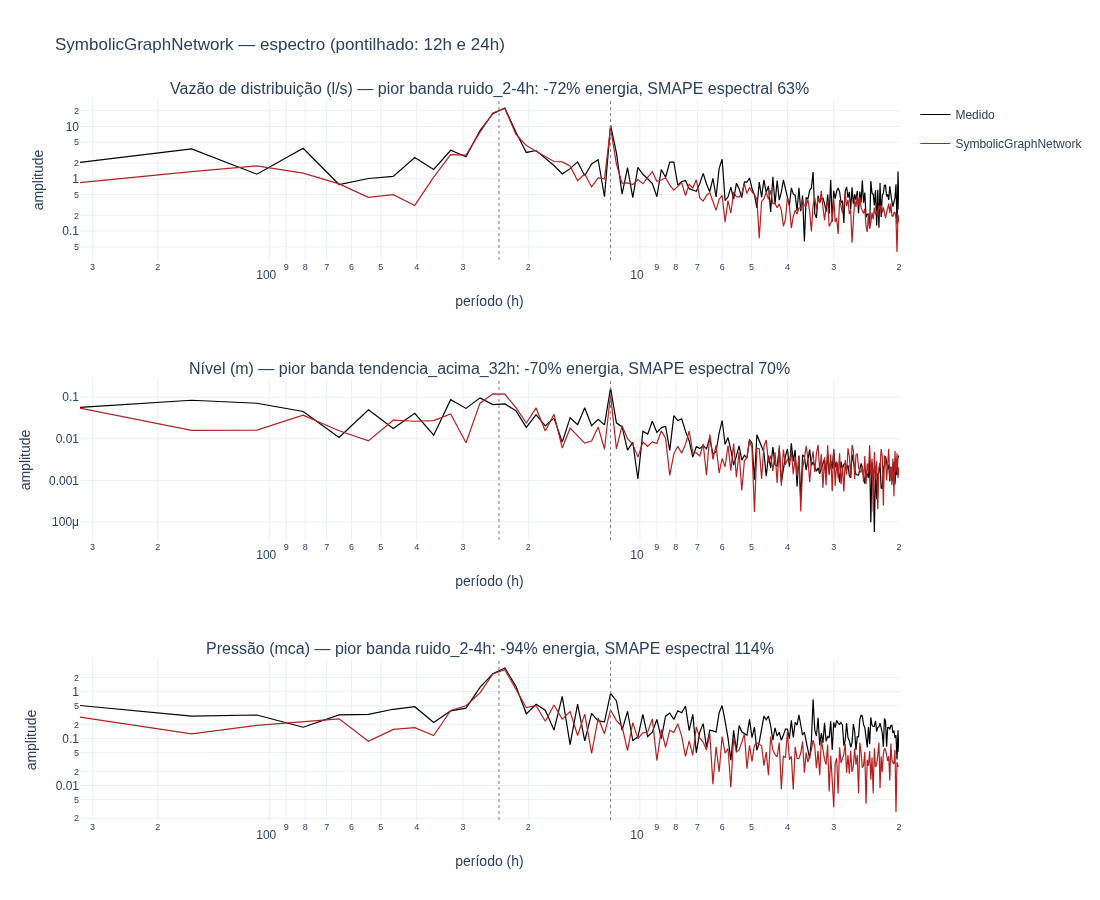

In [10]:
from IPython.display import Image
from mlflow.tracking import MlflowClient

client = MlflowClient()


def show_artifact(modelo: str, nome: str) -> Image:
    """Baixa e mostra um PNG de artefato do run de `modelo`.

    `nome` é o caminho do artefato, ex. 'serie.png', 'espectro.png',
    'attention_lags.png', 'attention_nos.png'.
    """
    run_id = children.loc[modelo, "run_id"]
    local_path = client.download_artifacts(run_id, nome)
    return Image(local_path)


show_artifact("SymbolicGraphNetwork", "espectro.png")

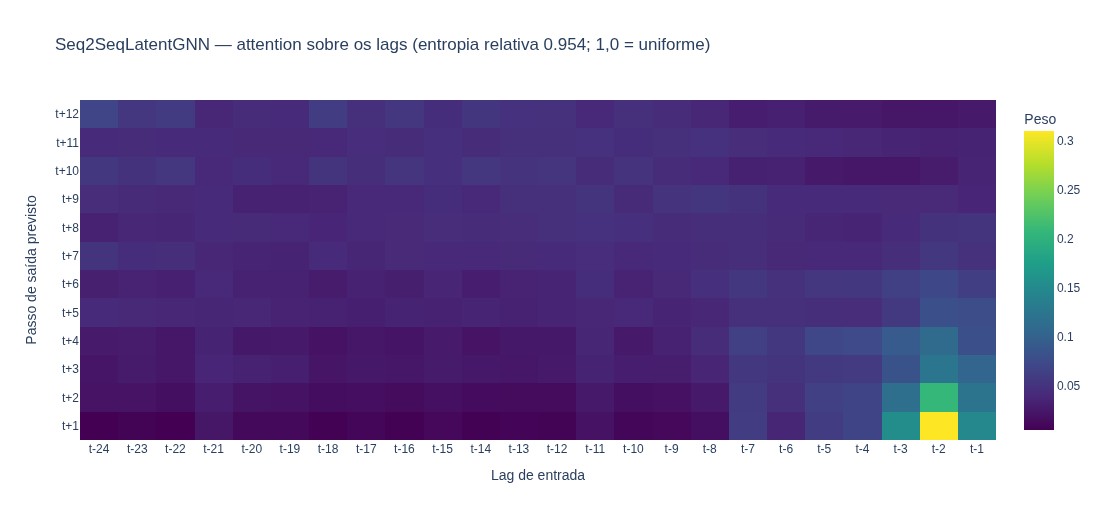

In [11]:
show_artifact("Seq2SeqLatentGNN", "attention_lags.png")

### Resumo do run pai

Os heatmaps de R² e de erro de energia por banda, agregando todos os
modelos — equivalente à aba *Artifacts* do run pai na UI.

In [12]:
parent_row = runs[runs["tags.mlflow.parentRunId"].isna()]
parent_run_id = parent_row["run_id"].iloc[0]
parent_row[["tags.mlflow.runName", "run_id"]]

,tags.mlflow.runName,run_id
7,collection_70_15_15,05c7c3d3a5874621a6b0c6a89738a200


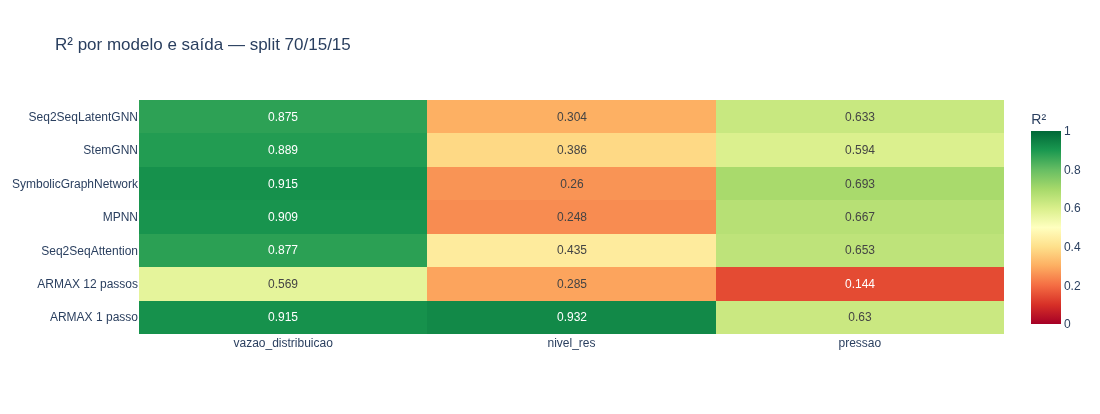

In [13]:
local_path = client.download_artifacts(parent_run_id, "resumo_r2.png")
Image(local_path)